In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sys
import re
import numpy as np

In [2]:
df = pd.read_csv("/kaggle/input/legalcon-dataset/LegalCon-Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   IDs                      1038 non-null   int64 
 1   Dialogue                 1038 non-null   object
 2   Manipulative             1038 non-null   int64 
 3   Primary Manipulator      635 non-null    object
 4   Manipulation Techniques  636 non-null    object
dtypes: int64(2), object(3)
memory usage: 40.7+ KB


In [3]:
df.head(10)

,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
0,804,**[Judge]**\nWelcome back to The People's Cour...,1,plaintiff,"gaslighting, deflection"
1,154,Judge: you shouldn't have a problem paying the...,1,defendant,"Minimization, Deflection"
2,566,Judge: But it says a notice to appear under Se...,0,NaN,NaN
3,594,"Judge: All parties, please raise your right ha...",1,defendant,"minimization,Deflection, dismissal"
4,116,"Judge:\nOkay, Elias Samas.\n\nPlaintiff:\nThat...",1,defendant,minimization deflection persuasion
5,780,Judge\n-- but I just want to understand what's...,0,NaN,NaN
6,558,"Judge: All parties, please welcome back to the...",1,plaintiff,"deflection, minimization, persuasion"
7,762,"Judge: ""But you had told him, 'I'm pregnant ei...",1,defendant,"Minimization, deflection"
8,656,"Judge: Tracy Unique Alexander. Yes, you are su...",1,defendant,"character attack, playing the victim, gaslight..."
9,956,Judge: So all of this money and he hasn't give...,1,defendant,"Minimization, Evasion"


In [4]:
df.nunique()

IDs                        1038
Dialogue                   1035
Manipulative                  2
Primary Manipulator          11
Manipulation Techniques     485
dtype: int64

In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))
print(f"\nTotal rows with any missing values: {df.isnull().any(axis=1).sum()}")

Missing values in each column:
IDs                          0
Dialogue                     0
Manipulative                 0
Primary Manipulator        403
Manipulation Techniques    402
dtype: int64

Missing values percentage:
IDs                         0.00
Dialogue                    0.00
Manipulative                0.00
Primary Manipulator        38.82
Manipulation Techniques    38.73
dtype: float64

Total rows with any missing values: 403


 Distribution of 'Manipulative' Label
Counts:
 Manipulative
1    636
0    402
Name: count, dtype: int64

Percentage %:
 Manipulative
1    61.271676
0    38.728324
Name: proportion, dtype: float64


Text(0, 0.5, 'Count')

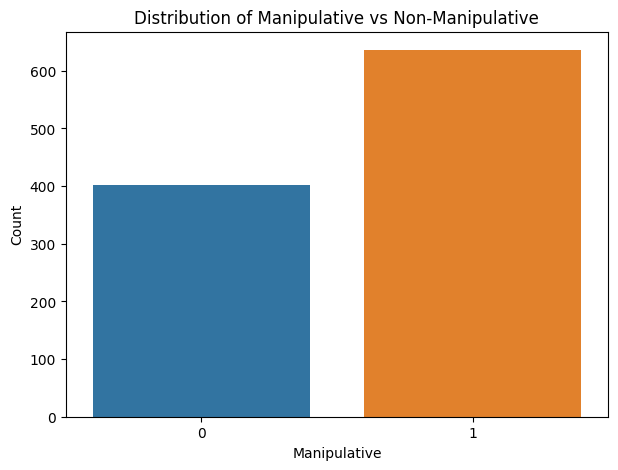

In [6]:
print(" Distribution of 'Manipulative' Label")
manipulative_counts = df['Manipulative'].value_counts()
manipulative_percent = df['Manipulative'].value_counts(normalize=True) * 100
print("Counts:\n", manipulative_counts)
print("\nPercentage %:\n", manipulative_percent)

plt.figure(figsize=(7, 5))
sns.barplot(x=manipulative_counts.index, y=manipulative_counts.values)
plt.title('Distribution of Manipulative vs Non-Manipulative')
plt.ylabel('Count')

## Clean Dialogue

In [7]:
dup_dialogues = df[df["Dialogue"].duplicated(keep=False)].sort_values("Dialogue")
print(f"Total duplicate dialogues found: {len(dup_dialogues)}")
print(f"Number of unique dialogue values that are duplicated: {dup_dialogues['Dialogue'].nunique()}")
dup_dialogues

Total duplicate dialogues found: 6
Number of unique dialogue values that are duplicated: 3


,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
78,272,"Judge:\nI think that the concern raised, thoug...",0,NaN,NaN
608,462,"Judge:\nI think that the concern raised, thoug...",0,NaN,NaN
442,776,"Judge: All parties, please raise your right ha...",1,plaintiff,"deflection, exxageration"
613,740,"Judge: All parties, please raise your right ha...",1,plaintiff,exaggeration
912,14,"Judge: This is the plaintiff, Shawn Dale Tatum...",1,defendant,"deflection, playing the victim"
939,773,"Judge: This is the plaintiff, Shawn Dale Tatum...",1,plaintiff,"deflection, playing the victim,gaslighting, ev..."


In [8]:
# Store counts before removing duplicates
rows_before = df.shape[0]
duplicates_count = df['Dialogue'].duplicated(keep='first').sum()

# Remove duplicates
df.drop_duplicates(subset=['Dialogue'], keep='first', inplace=True)

# Print validation
print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates: {df.shape[0]}")
print(f"Duplicates removed: {duplicates_count}")
print(f"Remaining missing values in Dialogue: {df['Dialogue'].isnull().sum()}")

Rows before removing duplicates: 1038
Rows after removing duplicates: 1035
Duplicates removed: 3
Remaining missing values in Dialogue: 0


Word Count Statistics:
count    1035.000000
mean      880.252174
std       503.051237
min        35.000000
25%       642.500000
50%       931.000000
75%      1135.500000
max      2742.000000
Name: word_count, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


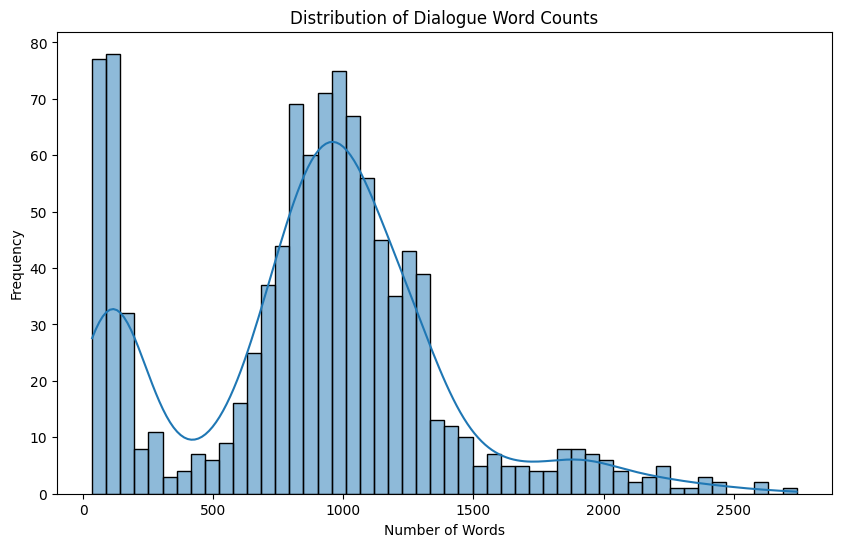

In [9]:
df['word_count'] = df['Dialogue'].apply(lambda x: len(str(x).split()))

print("Word Count Statistics:")
print(df['word_count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Dialogue Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
del df['word_count']

## Clean Primary Manipulator

In [10]:
print(f"Number of unique values in 'Primary Manipulator': {df['Primary Manipulator'].nunique()}")
print(f"Total rows: {df.shape[0]}")
print(f"\nUnique values:")
print(df['Primary Manipulator'].unique())

Number of unique values in 'Primary Manipulator': 11
Total rows: 1035

Unique values:
['plaintiff' 'defendant' nan 'Defendant' 'defendent' 'Plaintiff'
 'plaintiff ' 'pLaintiff' 'defendanr' "Plaintiff's lawyer"
 "Defendant's Lawyer" ' defendant']


In [11]:
df["Primary Manipulator"] = (
    df["Primary Manipulator"]     
    .str.strip()                   
    .str.lower()                   
    .replace({
        "defendent": "defendant",   
        "defendanr": "defendant",   
    })
    .str.title()                   
)
df["Primary Manipulator"].unique()

array(['Plaintiff', 'Defendant', nan, "Plaintiff'S Lawyer",
       "Defendant'S Lawyer"], dtype=object)

In [12]:
print("Validation after normalization:")
print(f"Unique values count: {df['Primary Manipulator'].nunique()}")
print(f"Missing values: {df['Primary Manipulator'].isnull().sum()}")

Validation after normalization:
Unique values count: 4
Missing values: 402



Distribution of 'Primary_Manipulator' Label
Counts:
 Primary Manipulator
Defendant             439
Plaintiff             192
Plaintiff'S Lawyer      1
Defendant'S Lawyer      1
Name: count, dtype: int64

Percentage %:
 Primary Manipulator
Defendant             69.352291
Plaintiff             30.331754
Plaintiff'S Lawyer     0.157978
Defendant'S Lawyer     0.157978
Name: proportion, dtype: float64


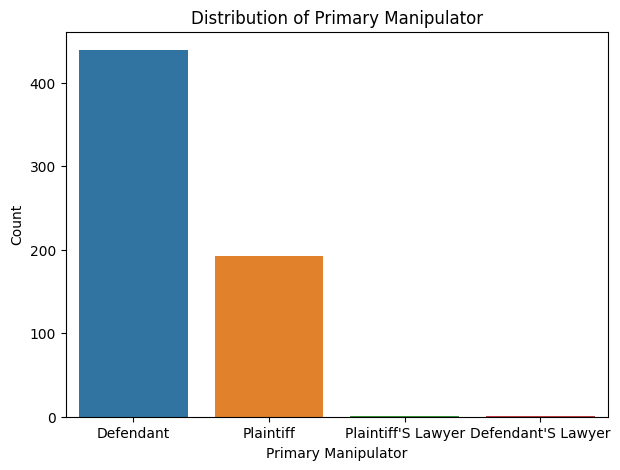

In [13]:
print("\nDistribution of 'Primary_Manipulator' Label")
manipulator_counts = df['Primary Manipulator'].value_counts()
manipulator_percent = df['Primary Manipulator'].value_counts(normalize=True) * 100
print("Counts:\n", manipulator_counts)
print("\nPercentage %:\n", manipulator_percent)

plt.figure(figsize=(7, 5))
sns.barplot(x=manipulator_counts.index, y=manipulator_counts.values)
plt.title('Distribution of Primary Manipulator')
plt.ylabel('Count')
plt.show()

In [14]:
rows_before_filter = df.shape[0]
df = df[~df['Primary Manipulator'].str.lower().str.contains('lawyer', na=False)]

print(f"Rows before filtering: {rows_before_filter}")
print(f"Rows after filtering: {df.shape[0]}")
print(f"Lawyer entries removed: {rows_before_filter - df.shape[0]}")
print("\nAfter removing lawyer entries:")
print(df['Primary Manipulator'].value_counts())
print("\nPercentage:")
print(df['Primary Manipulator'].value_counts(normalize=True) * 100)

Rows before filtering: 1035
Rows after filtering: 1033
Lawyer entries removed: 2

After removing lawyer entries:
Primary Manipulator
Defendant    439
Plaintiff    192
Name: count, dtype: int64

Percentage:
Primary Manipulator
Defendant    69.572108
Plaintiff    30.427892
Name: proportion, dtype: float64


## Clean Manipulation Techniques

In [15]:
print(f"Number of unique values in 'Manipulation Techniques': {df['Manipulation Techniques'].nunique()}")
print(f"Missing values: {df['Manipulation Techniques'].isnull().sum()}")
print(f"\nSample unique values (first 20):")
print(df['Manipulation Techniques'].unique()[:20])

Number of unique values in 'Manipulation Techniques': 483
Missing values: 401

Sample unique values (first 20):
[' gaslighting, deflection' 'Minimization, Deflection' nan
 'minimization,Deflection, dismissal' 'minimization deflection persuasion'
 'deflection, minimization, persuasion' 'Minimization, deflection'
 'character attack, playing the victim, gaslighting, dismissal, deflection'
 'Minimization, Evasion' 'Minimization,Deflection ,Emotional Framing'
 'evasion, persuasion' 'Deflection, Guilt Tripping'
 ' Gaslighting,Minimization,Deflection' 'minimization, gaslighting'
 'playing the victim' 'minimization, deflection, persuasion'
 'emotional appeal, deflection'
 'Deflection , Minimization, Emotional Appeal, Gaslighting' ', deflection'
 'deflection, dismissal, minimization, exaggeration, emotional appeal']


In [16]:
# Define canonical techniques with order
canonical_techniques_ordered = {
    "gaslighting": 1, "guilt tripping": 2, "persuasion": 3, "evasion": 4,
    "framing the narrative": 5, "dismissal": 6, "character attack": 7,
    "deflection": 8, "minimization": 9, "emotional appeal": 10,
    "playing the victim": 11
}

# Normalization map for common typos and variants
normalization_map = {
    "playing the victim role": "playing the victim", 
    "victim playing": "playing the victim",
    "plaing the victim": "playing the victim", 
    "guilt-tripping": "guilt tripping",
    "guilttripping": "guilt tripping", 
    "guilt - tripping": "guilt tripping",
    "emotional appealing": "emotional appeal", 
    "emtional appeal": "emotional appeal",
    "emotion appeal": "emotional appeal", 
    "appeal to emotion": "emotional appeal",
    "emotional blackmailing": "emotional appeal", 
    "framing narrative": "framing the narrative",
    "gasligting": "gaslighting", 
    "defelction": "deflection",
}

print(f" Defined {len(canonical_techniques_ordered)} canonical techniques")
print(f" Defined {len(normalization_map)} normalization mappings")

 Defined 11 canonical techniques
 Defined 14 normalization mappings


In [17]:
# Prepare technique lists for processing
allowed_techniques_set = set(canonical_techniques_ordered.keys())
multi_word_techniques = sorted([t for t in allowed_techniques_set if ' ' in t], key=len, reverse=True)
single_word_techniques = sorted([t for t in allowed_techniques_set if ' ' not in t], key=len, reverse=True)

print(f"Multi-word techniques ({len(multi_word_techniques)}):")
for tech in multi_word_techniques:
    print(f"  - {tech}")
print(f"\nSingle-word techniques ({len(single_word_techniques)}):")
for tech in single_word_techniques:
    print(f"  - {tech}")

Multi-word techniques (5):
  - framing the narrative
  - playing the victim
  - emotional appeal
  - character attack
  - guilt tripping

Single-word techniques (6):
  - minimization
  - gaslighting
  - persuasion
  - deflection
  - dismissal
  - evasion


In [18]:
def clean_manipulation_techniques(text):
    """
    Clean and normalize manipulation techniques text.
    
    Args:
        text: Raw technique string (may contain multiple techniques)
        
    Returns:
        Cleaned, sorted, comma-separated technique string or NaN if empty
    """
    if pd.isna(text):
        return np.nan
    
    # Step 1: Basic cleaning
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip().lower()  # Normalize whitespace
    text = re.sub(r'[.,;]+$', '', text).strip()       # Remove trailing punctuation
    
    if not text:
        return np.nan
    
    found_techniques = set()
    
    # Step 2: Apply normalization map for multi-word techniques
    temp_text = text
    for variant, canonical in normalization_map.items():
        if ' ' in canonical:  # Multi-word canonical
            temp_text = re.sub(r'\b' + re.escape(variant) + r'\b', canonical, temp_text)
    
    # Step 3: Extract multi-word techniques (avoiding overlaps)
    processed_indices = []
    for tech in multi_word_techniques:
        for match in re.finditer(r'\b' + re.escape(tech) + r'\b', temp_text):
            start, end = match.span()
            # Check for overlap with already processed techniques
            is_overlapping = any(
                max(start, p_start) < min(end, p_end) 
                for p_start, p_end in processed_indices
            )
            if not is_overlapping:
                found_techniques.add(tech)
                processed_indices.append((start, end))
    
    # Step 4: Extract remaining text (parts not covered by multi-word techniques)
    processed_indices.sort()
    remaining_parts = []
    last_end = 0
    for start, end in processed_indices:
        remaining_parts.append(temp_text[last_end:start])
        last_end = end
    remaining_parts.append(temp_text[last_end:])
    remaining_text = ' '.join(remaining_parts).strip()
    
    # Step 5: Extract single-word techniques from remaining text
    potential_words = re.split(r'\s*[,&/]\s*|\s+', remaining_text)
    for word in potential_words:
        word = word.strip().strip('.,;')
        if not word:
            continue
        # Apply normalization
        normalized = normalization_map.get(word, word)
        if normalized in single_word_techniques:
            found_techniques.add(normalized)
    
    # Step 6: Sort and format output
    if not found_techniques:
        return np.nan
    
    sorted_techniques = sorted(
        list(found_techniques), 
        key=lambda t: canonical_techniques_ordered[t]
    )
    return ', '.join(sorted_techniques)

print("Cleaning function defined successfully")

Cleaning function defined successfully


In [19]:
# Apply cleaning function
print("Cleaning 'Manipulation Techniques' column...")
print(f"Original unique values: {df['Manipulation Techniques'].nunique()}")
print(f"Original missing values: {df['Manipulation Techniques'].isnull().sum()}")

# Store original for comparison
df['Original_Techniques'] = df['Manipulation Techniques']

# Apply cleaning
df['Manipulation Techniques'] = df['Manipulation Techniques'].apply(clean_manipulation_techniques)

print(f"\nCleaning complete!")
print(f"After cleaning unique values: {df['Manipulation Techniques'].nunique()}")
print(f"After cleaning missing values: {df['Manipulation Techniques'].isnull().sum()}")

Cleaning 'Manipulation Techniques' column...
Original unique values: 483
Original missing values: 401

Cleaning complete!
After cleaning unique values: 161
After cleaning missing values: 404


In [20]:
# Validate cleaning results
print("=== CLEANING VALIDATION ===\n")

# Show sample comparisons
print("Sample Before vs After Cleaning:")
sample_changed = df[df['Original_Techniques'] != df['Manipulation Techniques']].head(10)
if not sample_changed.empty:
    for idx, row in sample_changed.iterrows():
        print(f"\nBefore: {row['Original_Techniques']}")
        print(f"After:  {row['Manipulation Techniques']}")
else:
    print("No changes detected in sample")

# Show technique distribution
print("\n\nTechnique Distribution (cleaned):")
technique_counts = df['Manipulation Techniques'].value_counts()
print(technique_counts.head(20))

=== CLEANING VALIDATION ===

Sample Before vs After Cleaning:

Before:  gaslighting, deflection
After:  gaslighting, deflection

Before: Minimization, Deflection
After:  deflection, minimization

Before: nan
After:  nan

Before: minimization,Deflection, dismissal
After:  dismissal, deflection, minimization

Before: minimization deflection persuasion
After:  persuasion, deflection, minimization

Before: nan
After:  nan

Before: deflection, minimization, persuasion
After:  persuasion, deflection, minimization

Before: Minimization, deflection
After:  deflection, minimization

Before: character attack, playing the victim, gaslighting, dismissal, deflection
After:  gaslighting, dismissal, character attack, deflection, playing the victim

Before: Minimization, Evasion
After:  evasion, minimization


Technique Distribution (cleaned):
Manipulation Techniques
deflection                                                       35
deflection, minimization                                         33


In [21]:
# Remove rows with Manipulative=1 but no techniques (data quality issue)
original_rows = df.shape[0]

# Identify problematic rows
rows_to_delete_mask = (df['Manipulation Techniques'].isna()) & (df['Manipulative'] == 1)
deleted_rows_df = df[rows_to_delete_mask].copy()

# Remove problematic rows
df = df[~rows_to_delete_mask].copy()

# Report
rows_deleted = deleted_rows_df.shape[0]

print(f"Original rows: {original_rows}")
print(f"Rows after filtering: {df.shape[0]}")
print(f"Rows deleted (Manipulative=1 but no techniques): {rows_deleted}")
print(f"Percentage deleted: {(rows_deleted/original_rows*100):.2f}%")

if rows_deleted > 0:
    print(f"\n  Deleted {rows_deleted} rows with inconsistent labels")

Original rows: 1033
Rows after filtering: 1030
Rows deleted (Manipulative=1 but no techniques): 3
Percentage deleted: 0.29%

  Deleted 3 rows with inconsistent labels


In [22]:
# Show deleted rows (if any) for review
if rows_deleted > 0:
    print("\n=== DELETED ROWS SAMPLE ===")
    print("\nFirst 10 deleted rows:")
    display_cols = ['Manipulative', 'Original_Techniques', 'Manipulation Techniques', 'Dialogue']
    available_cols = [col for col in display_cols if col in deleted_rows_df.columns]
    print(deleted_rows_df[available_cols].head(10).to_string())
else:
    print("\nNo rows deleted - data quality is good!")


=== DELETED ROWS SAMPLE ===

First 10 deleted rows:
     Manipulative            Original_Techniques Manipulation Techniques                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [23]:
# Final statistics for Manipulation Techniques
print("=== FINAL MANIPULATION TECHNIQUES STATISTICS ===\n")

# Overall stats
print(f"Total rows: {df.shape[0]}")
print(f"Rows with techniques: {df['Manipulation Techniques'].notna().sum()}")
print(f"Rows without techniques: {df['Manipulation Techniques'].isna().sum()}")
print(f"Unique technique combinations: {df['Manipulation Techniques'].nunique()}")

# Distribution by Manipulative label
print("\nDistribution by Manipulative label:")
print(df.groupby('Manipulative')['Manipulation Techniques'].apply(lambda x: x.notna().sum()))

# Most common techniques
print("\n\nTop 15 most common technique combinations:")
print(df['Manipulation Techniques'].value_counts().head(15))

=== FINAL MANIPULATION TECHNIQUES STATISTICS ===

Total rows: 1030
Rows with techniques: 629
Rows without techniques: 401
Unique technique combinations: 161

Distribution by Manipulative label:
Manipulative
0      0
1    629
Name: Manipulation Techniques, dtype: int64


Top 15 most common technique combinations:
Manipulation Techniques
deflection                                              35
deflection, minimization                                33
evasion, deflection                                     26
gaslighting, evasion, deflection                        18
emotional appeal                                        17
gaslighting                                             16
gaslighting, deflection, playing the victim             16
minimization                                            16
gaslighting, evasion, deflection, playing the victim    15
persuasion, deflection, minimization                    15
gaslighting, deflection                                 14
evasion, defl

In [24]:
df = df.drop(columns=['Original_Techniques', 'IDs'])

In [25]:
# Final validation before splitting
print("=== FINAL DATA VALIDATION ===")
print(f"\nDataset shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\n'Manipulative' distribution:")
print(df['Manipulative'].value_counts())
print(f"\nPercentage:")
print(df['Manipulative'].value_counts(normalize=True) * 100)

=== FINAL DATA VALIDATION ===

Dataset shape: (1030, 4)

Missing values:
Dialogue                     0
Manipulative                 0
Primary Manipulator        402
Manipulation Techniques    401
dtype: int64

Data types:
Dialogue                   object
Manipulative                int64
Primary Manipulator        object
Manipulation Techniques    object
dtype: object

'Manipulative' distribution:
Manipulative
1    629
0    401
Name: count, dtype: int64

Percentage:
Manipulative
1    61.067961
0    38.932039
Name: proportion, dtype: float64


In [26]:
df.nunique()

Dialogue                   1030
Manipulative                  2
Primary Manipulator           2
Manipulation Techniques     161
dtype: int64

In [27]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42 

# First split: Train vs (Val + Test) with stratification
df_train, df_temp = train_test_split(
    df,
    test_size=(1 - TRAIN_SIZE),
    random_state=RANDOM_STATE,
    stratify=df['Manipulative']  # Stratify to maintain class balance
)

# Second split: Val vs Test with stratification
val_test_split_ratio = TEST_SIZE / (VAL_SIZE + TEST_SIZE)  

df_val, df_test = train_test_split(
    df_temp,
    test_size=val_test_split_ratio,
    random_state=RANDOM_STATE,
    stratify=df_temp['Manipulative']  # Stratify to maintain class balance
)

# Print split statistics
print("=== DATASET SPLIT SUMMARY ===")
print(f"\nTotal samples: {len(df)}")
print(f"  Train set:      {len(df_train)} samples ({len(df_train)/len(df):.1%})")
print(f"  Validation set: {len(df_val)} samples ({len(df_val)/len(df):.1%})")
print(f"  Test set:       {len(df_test)} samples ({len(df_test)/len(df):.1%})")

# Verify class distribution in each split
print("\n=== CLASS DISTRIBUTION ===")
print(f"\nOriginal dataset:")
print(df['Manipulative'].value_counts(normalize=True) * 100)
print(f"\nTrain set:")
print(df_train['Manipulative'].value_counts(normalize=True) * 100)
print(f"\nValidation set:")
print(df_val['Manipulative'].value_counts(normalize=True) * 100)
print(f"\nTest set:")
print(df_test['Manipulative'].value_counts(normalize=True) * 100)

# Save to CSV
df_train.to_csv("train_split.csv", index=False)
df_val.to_csv("val_split.csv", index=False)
df_test.to_csv("test_split.csv", index=False)

print("\nFiles saved successfully!")

=== DATASET SPLIT SUMMARY ===

Total samples: 1030
  Train set:      720 samples (69.9%)
  Validation set: 155 samples (15.0%)
  Test set:       155 samples (15.0%)

=== CLASS DISTRIBUTION ===

Original dataset:
Manipulative
1    61.067961
0    38.932039
Name: proportion, dtype: float64

Train set:
Manipulative
1    61.111111
0    38.888889
Name: proportion, dtype: float64

Validation set:
Manipulative
1    60.645161
0    39.354839
Name: proportion, dtype: float64

Test set:
Manipulative
1    61.290323
0    38.709677
Name: proportion, dtype: float64

Files saved successfully!
